In [12]:
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import json, csv, time, os, datetime

In [2]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    # 归一化参数来自FindNormParam.ipynb计算结果
])

In [3]:
full_trainset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True,
    download=True,
    transform=transform
)
trainset, valset = torch.utils.data.random_split(full_trainset, [45000, 5000])
testset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=False,
    download=True,
    transform=transform
)

classes = (
    'plane', 'car', 'bird', 'cat', 'deer', 
    'dog', 'frog', 'horse', 'ship', 'truck'
)

In [4]:
trainloader = torch.utils.data.DataLoader(
    trainset, 
    batch_size=128, 
    shuffle=True, 
    num_workers=4
)
valloader = torch.utils.data.DataLoader(
    valset,
    batch_size=128,
    shuffle=False,
    num_workers=4
)
testloader = torch.utils.data.DataLoader(
    testset, 
    batch_size=128, 
    shuffle=False, 
    num_workers=4
)

In [ ]:
def imshow(dataloader, classes, images=None, labels=None): # 逆归一化，可复用同一批样本
    if images is None or labels is None:
        images, labels = next(iter(dataloader))
    img = images[0].clone() # 取第一个样本
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    # 参数来源同上
    
    img = img.numpy().transpose((1, 2, 0)) # 从 [C, H, W] 变为 [H, W, C]
    img = std * img + mean # 逆归一化
    img = np.clip(img, 0, 1) # 限制在 0-1 之间
    plt.title(f"Target: {classes[labels[0]]}")
    plt.axis('off')
    plt.imshow(img)
    return images, labels  # 返回以便复用

for _ in range(20):
    imshow(trainloader, classes)
    plt.show()

In [5]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 3, padding=1) # 输入(3, 32, 32)，输出(6, 32, 32)， 32 = (32 - 3 + 2*1) / 1 + 1
        self.pool = nn.MaxPool2d(2, 2) # 池化操作，压缩降维
        self.conv2 = nn.Conv2d(6, 16, 3, padding=1) # 输入(6, 16, 16)，输出(16, 16, 16)，16 = (16 - 3 + 2*1) / 1 + 1
        self.fc1 = nn.Linear(16 * 8 * 8, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 16 * 8 * 8)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = Net().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

In [7]:
print("Using device:", device)

Using device: cuda


In [8]:
epochs = 10
train_acc_lst = []
val_acc_lst = []

for epoch in range(epochs):
    net.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total
    train_acc_lst.append(train_acc)

    net.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100. * val_correct / val_total
    val_acc_lst.append(val_acc)

    print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(trainloader):.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

Epoch 1/10, Loss: 1.6896, Train Acc: 38.85%, Val Acc: 47.80%
Epoch 2/10, Loss: 1.3603, Train Acc: 51.11%, Val Acc: 54.42%
Epoch 3/10, Loss: 1.2134, Train Acc: 56.71%, Val Acc: 54.94%
Epoch 4/10, Loss: 1.1185, Train Acc: 60.11%, Val Acc: 59.58%
Epoch 5/10, Loss: 1.0403, Train Acc: 62.96%, Val Acc: 60.56%
Epoch 6/10, Loss: 0.9844, Train Acc: 65.19%, Val Acc: 61.62%
Epoch 7/10, Loss: 0.9316, Train Acc: 67.00%, Val Acc: 62.02%
Epoch 8/10, Loss: 0.8796, Train Acc: 68.84%, Val Acc: 62.72%
Epoch 9/10, Loss: 0.8345, Train Acc: 70.46%, Val Acc: 62.22%
Epoch 10/10, Loss: 0.7968, Train Acc: 71.83%, Val Acc: 62.88%


In [ ]:
run_log = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "model": "Net",
    "epochs": epochs,
    "batch_size": 128,
    "optimizer": "Adam",
    "lr": 0.001,
    "train_acc_last": train_acc_lst[-1],
    "val_acc_last": val_acc_lst[-1],
    "train_acc_history": train_acc_lst,
    "val_acc_history": val_acc_lst,
}

# 1) 追加保存到 JSONL（每行一个实验）
jsonl_path = "runs.jsonl"
with open(jsonl_path, "a", encoding="utf-8") as f:
    f.write(json.dumps(run_log) + "\n")

# 2) 同时记录到 CSV，便于表格查看（只保留关键字段）
csv_path = "runs.csv"
csv_fields = ["timestamp", "model", "epochs", "batch_size", "optimizer", "lr", "train_acc_last", "val_acc_last"]
file_exists = os.path.exists(csv_path)
with open(csv_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=csv_fields)
    if not file_exists:
        writer.writeheader()
    writer.writerow({k: run_log[k] for k in csv_fields})

print("Logged to", jsonl_path, "and", csv_path)

In [ ]:
def safe_visualize_features(model, dataloader, layer_name='conv1', device=None, image_tensor=None):
    device = device or next(model.parameters()).device
    model.eval()
    if image_tensor is None:
        image_tensor = next(iter(dataloader))[0][:1]
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        conv1_feats = model.conv1(image_tensor)
        conv2_feats = model.conv2(model.pool(torch.relu(conv1_feats)))

    feats_map = {'conv1': conv1_feats, 'conv2': conv2_feats}
    for name in (['conv1', 'conv2'] if layer_name == 'both' else [layer_name]):
        feats = feats_map[name].detach().cpu().numpy()
        fig, axes = plt.subplots(4, 4, figsize=(8, 8))
        for i, ax in enumerate(axes.flat):
            if i < feats.shape[1]:
                ax.imshow(feats[0, i], cmap='viridis')
            ax.axis('off')
        plt.suptitle(f"{name} feature maps")
        plt.show()
    model.train()

# 使用同一张图像：先取一批，再复用
a_sample_images, a_sample_labels = next(iter(trainloader))
imshow(trainloader, classes, images=a_sample_images, labels=a_sample_labels)
safe_visualize_features(net, trainloader, layer_name='both', image_tensor=a_sample_images[:1])

Saved plot to Charts/train_val_acc_20251221-145834.png


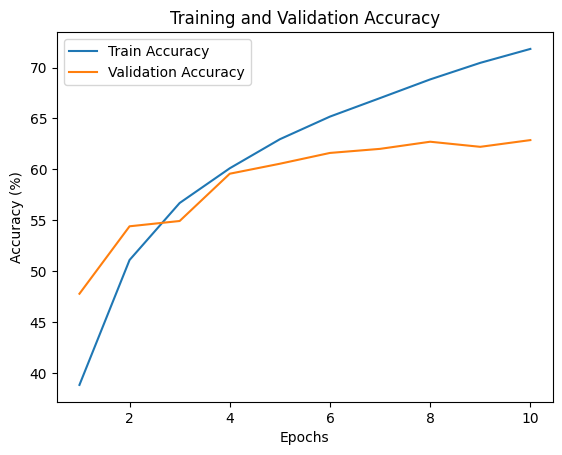

In [ ]:
plt.plot(range(1, epochs+1), train_acc_lst, label='Train Accuracy')
plt.plot(range(1, epochs+1), val_acc_lst, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()

os.makedirs('Charts', exist_ok=True)
timestamp = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
fig_path = f"Charts/train_val_acc_{timestamp}.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {fig_path}")

plt.show()

In [13]:
# 保存模型
save_folder = './saved_models'
model_name = 'Net'
epoch = epochs
val_acc = val_acc_lst[-1]
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")

os.makedirs(save_folder, exist_ok=True)
filename = f"{model_name}_{timestamp}_ep{epoch}_acc{val_acc:.3f}.pth"
save_path = os.path.join(save_folder, filename)
torch.save(net.state_dict(), save_path)

print(f"模型参数已保存至: {save_path}")

模型参数已保存至: ./saved_models/Net_20251221_1514_ep10_acc62.880.pth
